# Example 14: MDL

Minimum Description Length (MDL) is a principle in information theory and statistics used for model selection and compression. It provides a framework for choosing the best model to describe a given dataset by balancing the complexity of the model and the accuracy of the fit, not unlike AIC and BIC. The fundamental idea behind MDL is to select the model that results in the shortest description length of both the model and the data combined.

In the example below, we compute MDL and use it to perform subset selection for a dataset. 

In [1]:
# Standard imports and abbreviations
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

# Tools and metrics for linear regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# For defining all subsets
import itertools

The dataset in this example has a ground truth of $Y = 2X_0 - 3.5X_1 \epsilon$. We also generate variables for plotting the ground truth.  We will use the validation set to evaluate the model using MDL. The lower the score, the better the model. 

We break down the dataset to be 60% training, 20% validation, and 20% testing. 

In [2]:
# Generate synthetic data
np.random.seed(14)
X = np.random.rand(250, 6)  # 100 samples, 5 features
y = 2 * X[:, 0] - 3.5 * X[:, 1] + np.random.normal(0, 0.75, 250)

# Used for plotting results and ground truth
X_range = np.linspace(0, 1, 500)
y_truth = 2 * X_range - 3.5 * X_range + 1

# Split the data into training, validation, and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=14)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=14)

# for fitting the function once hyperparameters are selected
X_train_val = np.concatenate((X_train, X_val))
y_train_val = np.concatenate((y_train, y_val))

Here, we calculate a crude score to estimate the minimum description length score. We sum the "model length" (the product of parameters with the natural log of the number of samples) with the "data length" (the product of the number of samples with the natural log of the mean squared error of the estimated model)

In [3]:
def calculate_mdl(X_subset:np.ndarray, y:np.ndarray,
                  X_val:np.ndarray, y_val:np.ndarray) -> float:
    """
    Return MDL score for the given subset of features.
    """

    # Calculate Model
    n, k = X_subset.shape
    model = LinearRegression()
    model.fit(X_subset, y)

    # Calculate MSE of validation set
    y_pred = model.predict(X_val)
    mse = mean_squared_error(y_val, y_pred)
    
    # Calculate model length (Lm)
    num_params = k + 1  # Including intercept
    Lm = num_params * np.log(n)  # Using a simple formula for model length

    # Calculate data length (Ld)
    Ld = n * np.log(mse) / 2  # Using negative log-likelihood
    
    # Calculate MDL score
    mdl_score = Lm + Ld
    
    return mdl_score

Here, we search all possible subsets of features and compute an MDL score. The best score and the corresponding set of features is printed and saved. 

In [4]:
# Perform subset selection using MDL
n, num_features = X.shape
best_subset = []
best_mdl_score = float('inf')
mdl_scores = []  # Store MDL scores
subsets = []  # Store the indices of selected features

for k in range(1, num_features + 1):
    for subset in itertools.combinations(range(num_features), k):
        X_subset = X_train[:, list(subset)]
        X_val_subset = X_val[:, list(subset)]
        mdl_score = calculate_mdl(X_subset, y_train, X_val_subset, y_val)
        
        # Store MDL score and corresponding subset indices
        mdl_scores.append(mdl_score)
        subsets.append(subset)
        
        if mdl_score < best_mdl_score:
            best_mdl_score = mdl_score
            best_subset = list(subset)

print("Best subset of features:", best_subset)
print("Best MDL score:", best_mdl_score)

Best subset of features: [0, 1]
Best MDL score: -2.6835860276980856


The next few cells are to compute a visualization of the features against the MDL score. Although this step isn't strictly necessary, it illustrates how much the mean squared error influences the MDL score versus the number of features. 

In order to plot this data, we map lists of features (e.g., $(0, 1, 3)$) to the product of the length times the sum (e.g., $3 \times 4 = 12$). This allows us to distinguish points on our graph. 

In [5]:
def is_subset(sublist:list, superlist:list) -> bool:
    """
    Returns True if sublist is inside superlist
    """
    
    for item in sublist:
        if item not in superlist:
            return False
    return True

In [6]:
# Create a list to hold colors for each subset based on the presence of 0, or 1
subset_colors = []
colors = ['red', 'green', 'blue', 'indigo']
labels = ['Contains 0, 1', 'Contains 0', 'Contains 1', 'Rest']

for subset in subsets:
    if is_subset([0, 1], subset):
        subset_colors.append('red')        
    elif is_subset([0], subset):
        subset_colors.append('green')
    elif is_subset([1], subset):
        subset_colors.append('blue')
    else:
        subset_colors.append('indigo')

In [7]:
# We map subsets onto the integers by multiplying the length by the sum
# Example: (0, 1, 2, 3) -> 24
subset_map = [len(subset)*sum(subset) for subset in subsets]

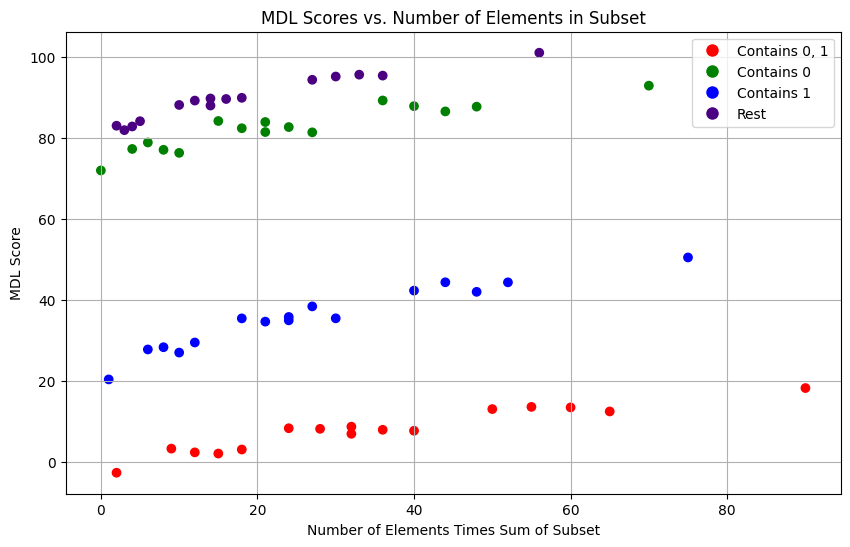

In [8]:
# Create the plot
plt.figure(figsize=(10, 6))
plt.scatter(subset_map, mdl_scores, c=subset_colors)
plt.xlabel('Number of Elements Times Sum of Subset')
plt.ylabel('MDL Score')
plt.title('MDL Scores vs. Number of Elements in Subset')
plt.grid(True)

# Add a legend for colors
patches = []
for i in range(len(colors)):
    patches.append(plt.Line2D([0], [0], marker='o', color='w', label=labels[i], markerfacecolor=colors[i], markersize=10))
plt.legend(handles=patches)

plt.show()

Lastly, let's compute the model associated to the best subset. We can consider metrics such as the coefficient of determination. We also graph the model with the testing set to illustate the fit. 

In [9]:
model = LinearRegression()
model.fit(X_train_val[:, best_subset], y_train_val)
y_pred_test = model.predict(X_test[:, best_subset])

test_mse = mean_squared_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)
print(f"Mean Squared Error on testing set with best subset ({best_subset}): {test_mse:.4f}")
print(f"R-squared on testing set with best subset ({best_subset}): {test_r2:.4f}")

Mean Squared Error on testing set with best subset ([0, 1]): 0.5782
R-squared on testing set with best subset ([0, 1]): 0.6369


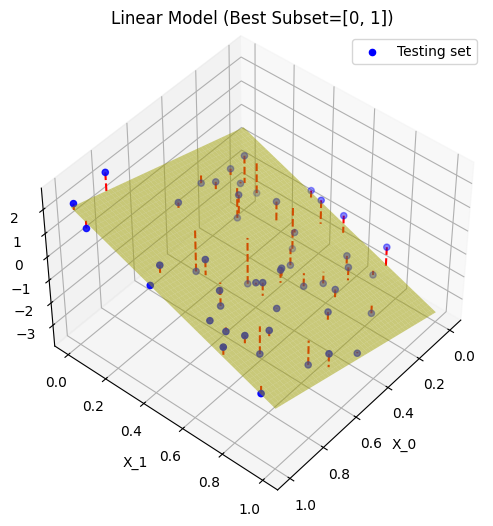

In [10]:
X0, X1 = np.meshgrid(X_range, X_range)
Z = model.coef_[0]*X0 + model.coef_[1]*X1 + model.intercept_
# Z_true = 2*X0 - 3.5*X1

# Plot the true plane and estimated plane
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot the plane
# surf_true = ax.plot_surface(X0, X1, Z_true, color='yellow', alpha=0.4)
surf_model = ax.plot_surface(X0, X1, Z, color='yellow', alpha=0.5)

# Testing set
ax.scatter(X_test[:,0], X_test[:,1], y_test, c='blue', label='Testing set', marker='o')

# Create dashed lines connecting test points to the estimated plane
for i in range(len(X_test)):
    x0 = X_test[i, 0]
    x1 = X_test[i, 1]
    z0 = y_test[i]
    z1 = model.coef_[0]*x0 + model.coef_[1]*x1 + model.intercept_
    ax.plot([x0, x0], [x1, x1], [z0, z1], color='red', linestyle='--')

ax.set_xlabel('X_0')
ax.set_ylabel('X_1')
ax.set_zlabel('Y')
ax.set_title(f'Linear Model (Best Subset={best_subset})')
ax.legend()

# Rotate the plot for better visualization (e.g., azimuth=45, elevation=30)
ax.view_init(azim=40, elev=45)

plt.show()